In [ ]:
# ======================================================
# Netflix Data Lab — SQLite or InfluxDB 3 (Colab Ready)
# Author: Group 6
# ======================================================

# ------------------------------
# Step 0: Choose Database
# ------------------------------
db_choice = "sqlite"



In [ ]:
# ------------------------------
# Step 1: Import Libraries
# ------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if db_choice == "sqlite":
    import sqlite3
elif db_choice == "influxdb":
    # !pip install influxdb3-python
    try:
        from influxdb_client_3 import InfluxDBClient
    except Exception as e:
        print("InfluxDB 3 client missing. In Colab, run: !pip install influxdb3-python")
        raise e

plt.rcParams['figure.figsize'] = (8, 5)

In [ ]:
# ------------------------------
# Step 2: Load Netflix Dataset
# ------------------------------
CSV_PATH = Path("netflix_titles.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError("❌ Missing netflix_titles.csv. Please upload it in Colab’s left file panel.")

netflix_df = pd.read_csv(CSV_PATH)
print(f"✅ Loaded dataset with {len(netflix_df):,} rows")

# 清洗数据
for col in ['show_id','type','title','director','cast','country','date_added','rating','duration','listed_in','description']:
    if col in netflix_df.columns and netflix_df[col].dtype == 'O':
        netflix_df[col] = netflix_df[col].astype(str).str.strip()

✅ Loaded dataset with 8,807 rows


In [ ]:
# ------------------------------
# Step 3: Database Setup
# ------------------------------
if db_choice == "sqlite":
    conn = sqlite3.connect("netflix.db")
    cur = conn.cursor()
    cur.execute("DROP TABLE IF EXISTS netflix")
    cur.execute("""
        CREATE TABLE netflix (
            show_id TEXT PRIMARY KEY,
            type TEXT,
            title TEXT,
            director TEXT,
            cast TEXT,
            country TEXT,
            date_added TEXT,
            release_year INTEGER,
            rating TEXT,
            duration TEXT,
            listed_in TEXT,
            description TEXT
        )
    """)
    conn.commit()
    netflix_df.to_sql("netflix", conn, if_exists="append", index=False)
    print("✅ SQLite database created and populated.")
elif db_choice == "influxdb":
    client = InfluxDBClient(
        host="us-east-1-1.aws.cloud2.influxdata.com",
        token="YOUR_TOKEN",
        org="YOUR_ORG"
    )
    bucket_name = "netflix_bucket"
    print("✅ InfluxDB client configured (please update credentials).")


✅ SQLite database created and populated.


In [ ]:
# ======================================================
# Step 4: Automated Insights — SQLite (clean version)
# ======================================================
# Fix for "nan" appearing in charts:
# 1. Convert "nan"/"NaN"/empty strings to true missing values (pd.NA)
# 2. Drop missing values when counting top items
# 3. Report how many rows had missing country data

if db_choice == "sqlite":
    df_all = pd.read_sql_query("SELECT country, listed_in FROM netflix", conn)

    # --- clean country column ---
    df_all["country"] = (
        df_all["country"]
        .astype("string")
        .str.strip()
        .replace(["", "nan", "NaN", "N/A"], pd.NA)
    )

    total_rows = len(df_all)
    unknown_country_cnt = df_all["country"].isna().sum()

    # --- split comma-separated values and explode ---
    countries = (
        df_all["country"]
        .dropna()
        .str.replace(r"\s*,\s*", ",", regex=True)
        .str.split(",")
        .explode()
        .str.strip()
    )

    df_country = (
        countries.to_frame(name="country")
        .groupby("country", as_index=False)
        .size()
        .rename(columns={"size": "total"})
        .sort_values("total", ascending=False)
        .head(5)
    )

    print(df_country)
    print(f"Unknown country (missing): {unknown_country_cnt} "
          f"({unknown_country_cnt/total_rows:.1%} of {total_rows})")

    # --- clean and split genres ---
    df_all["listed_in"] = (
        df_all["listed_in"]
        .astype("string")
        .str.strip()
        .replace(["", "nan", "NaN", "N/A"], pd.NA)
    )

    genres = (
        df_all["listed_in"]
        .dropna()
        .str.replace(r"\s*,\s*", ",", regex=True)
        .str.split(",")
        .explode()
        .str.strip()
    )

    df_genres = (
        genres.to_frame(name="genre")
        .groupby("genre", as_index=False)
        .size()
        .rename(columns={"size": "total"})
        .sort_values("total", ascending=False)
        .head(5)
    )

elif db_choice == "influxdb":
    df_country = pd.DataFrame(columns=["country","total"])
    df_genres = pd.DataFrame(columns=["genre","total"])
    print("➡ TODO: Implement InfluxDB queries.")


            country  total
116   United States   3690
46            India   1046
115  United Kingdom    806
21           Canada    445
37           France    393
Unknown country (missing): 831 (9.4% of 8807)


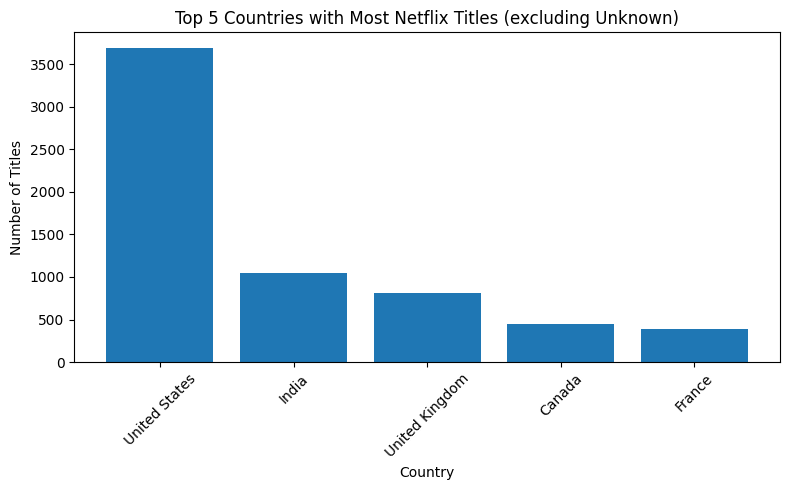

Note: Unknown country (missing) = 831 (9.4% of 8807)


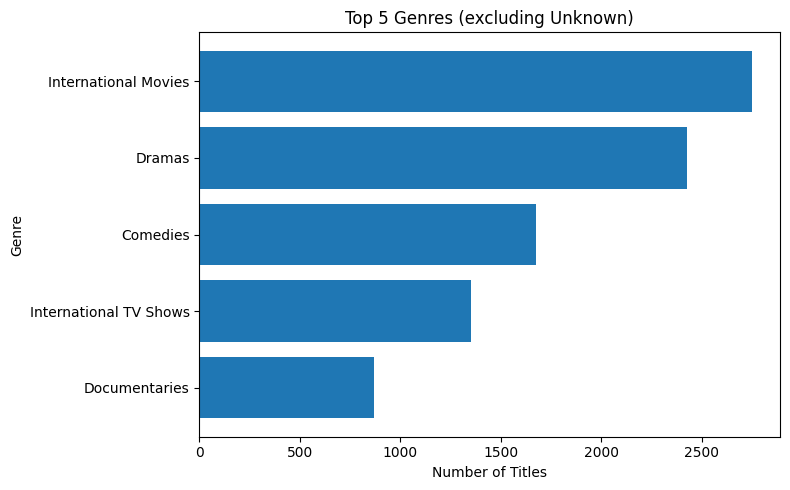

In [ ]:
# ======================================================
# Step 5: Visualization (updated for cleaned data)
# ======================================================
# Notes:
# - We now plot Top-K with missing values excluded.
# - Country chart uses df_country['country'] / ['total'].
# - Genre chart uses df_genres['genre'] / ['total'] (renamed in Step 4).
# - Optionally show a text note for how many rows had unknown country.

import matplotlib.pyplot as plt

# If you kept these from Step 4:
# total_rows and unknown_country_cnt

if not df_country.empty:
    plt.figure()
    plt.bar(df_country['country'], df_country['total'])
    plt.title('Top 5 Countries with Most Netflix Titles (excluding Unknown)')
    plt.xlabel('Country')
    plt.ylabel('Number of Titles')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Optional: print a short note about missing values
    try:
        print(f"Note: Unknown country (missing) = {unknown_country_cnt} "
              f"({unknown_country_cnt/total_rows:.1%} of {total_rows})")
    except NameError:
        pass  # variables not defined if you didn't compute them

if not df_genres.empty:
    plt.figure()
    plt.barh(df_genres['genre'], df_genres['total'])
    plt.title('Top 5 Genres (excluding Unknown)')
    plt.xlabel('Number of Titles')
    plt.ylabel('Genre')
    plt.gca().invert_yaxis()  # largest on top
    plt.tight_layout()
    plt.show()


In [ ]:
# ------------------------------
# Step 6: Simple NLI (Natural Language Interface)
# ------------------------------
intent_map = {
    "total shows": "SELECT COUNT(*) AS total FROM netflix",
    "top countries": None,  # handled via df_country
    "top genres": None,     # handled via df_genres
    "top movies": "SELECT title, release_year FROM netflix WHERE type='Movie' ORDER BY release_year DESC LIMIT 5",
    "recent shows": "SELECT title, release_year FROM netflix WHERE release_year >= 2020 ORDER BY release_year DESC LIMIT 5"
}

def format_df(df: pd.DataFrame, max_rows: int = 10) -> str:
    if df is None or df.empty:
        return "(no results)"
    return df.head(max_rows).to_string(index=False)

def nli_query(question: str):
    q = question.lower().strip()
    if db_choice == "sqlite":
        for intent, sql in intent_map.items():
            if intent in q:
                if intent == "top countries":
                    return format_df(df_country)
                if intent == "top genres":
                    return format_df(df_genres)
                if sql:
                    df = pd.read_sql_query(sql, conn)
                    return format_df(df)
        return "Sorry, I didn't understand that. Try: total shows / top countries / top genres / top movies / recent shows"
    elif db_choice == "influxdb":
        return "➡ TODO: Implement InfluxDB NLI."


In [ ]:
# ======================================================
# Step 7: Test NLI (updated for cleaned data)
# ======================================================
# Purpose:
# - Quickly verify that the NLI function returns readable outputs.
# - Safe printing with separators for clarity.
# - Optional: handle KeyError or missing data gracefully.

print("🔹 Test 1: Total number of shows")
print(nli_query("total shows"))
print("\n---\n")

print("🔹 Test 2: Top countries (excluding Unknown)")
print(nli_query("top countries"))
print("\n---\n")

print("🔹 Test 3: Top genres (excluding Unknown)")
print(nli_query("top genres"))
print("\n---\n")

print("🔹 Test 4: Recent shows (2020 and newer)")
print(nli_query("recent shows"))
print("\n✅ NLI test complete.")


🔹 Test 1: Total number of shows
 total
  8807

---

🔹 Test 2: Top countries (excluding Unknown)
       country  total
 United States   3690
         India   1046
United Kingdom    806
        Canada    445
        France    393

---

🔹 Test 3: Top genres (excluding Unknown)
                 genre  total
  International Movies   2752
                Dramas   2427
              Comedies   1674
International TV Shows   1351
         Documentaries    869

---

🔹 Test 4: Recent shows (2020 and newer)
                title  release_year
        Blood & Water          2021
            Ganglands          2021
Jailbirds New Orleans          2021
         Kota Factory          2021
        Midnight Mass          2021

✅ NLI test complete.


In [ ]:
# ------------------------------
# Step 8: Close Connection
# ------------------------------
if db_choice == "sqlite":
    conn.close()
    print("SQLite connection closed.")
else:
    print("InfluxDB session complete.")

SQLite connection closed.
